# Wikipedia Editing Behavior Analysis
## Exploratory Data Analysis

Version: 11/3/2025

This notebook does exploratory analysis on political events' correlation with Wikipedia editing behavior on Chinese Wikipedia pages related to Taiwan politics, to gain a sense of the overall pattern before doing the implementing prospectus design. 

All data reflects aggregated editing data of selected pages (775 pages related to presidential/legislative elections in 2016, 2020, 2024. The two elections occur on the same day in Taiwan after 2012.)


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
import json
from datetime import datetime, timedelta
from pathlib import Path
import matplotlib.font_manager as fm
import warnings

# Suppress font warnings (Chinese characters will still display correctly)
warnings.filterwarnings('ignore', category=UserWarning, message='.*Glyph.*missing from font.*')

# Find and set Chinese font
def get_chinese_font():
    """Find available Chinese fonts on the system"""
    chinese_fonts = ['Arial Unicode MS', 'PingFang SC', 'Heiti TC', 'STHeiti', 
                     'SimHei', 'Microsoft YaHei', 'WenQuanYi Zen Hei']
    
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    for font in chinese_fonts:
        if font in available_fonts:
            return font
    
    # If no Chinese font found, return default
    return 'DejaVu Sans'

# Set seaborn style FIRST
sns.set_style('whitegrid')
%matplotlib inline

# THEN set Chinese font (after seaborn to prevent override)
chinese_font = get_chinese_font()
plt.rcParams['font.sans-serif'] = [chinese_font]
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False  # Fix minus sign display
plt.rcParams['figure.figsize'] = (14, 6)

print(f"Using font: {chinese_font}")

Using font: Arial Unicode MS


## Load Data

Load the processed datasets and political events timeline.


In [12]:
# Load processed datasets
data_dir = Path('../data/processed')

df_daily = pd.read_csv(data_dir / 'daily_edits.csv', parse_dates=['date'])
df_pages = pd.read_csv(data_dir / 'page_statistics.csv')

# Load political events
with open('../data/events/political_events.json', 'r', encoding='utf-8') as f:
    events_data = json.load(f)
    events = pd.DataFrame(events_data['events'])
    events['date'] = pd.to_datetime(events['date'])

print(f"Loaded daily data for {df_pages.shape[0]} pages")
print(f"Tracking {len(events)} political events")


Loaded daily data for 775 pages
Tracking 3 political events


## 1. Overview Statistics


In [13]:
# Basic statistics
print("Dataset Overview")
print("=" * 60)
print(f"Pages: {len(df_pages)}")
print(f"Date range: {df_daily['date'].min()} to {df_daily['date'].max()}")
print(f"Total days: {len(df_daily['date'].unique())}")
print(f"Total edits: {df_daily['num_edits'].sum():,}")
print(f"\nTop 5 Most Edited Pages:")
print(df_pages.nlargest(5, 'total_edits')[['page_title', 'total_edits', 'unique_editors']])


Dataset Overview
Pages: 775
Date range: 2015-01-01 00:00:00 to 2024-12-31 00:00:00
Total days: 3653
Total edits: 150,146

Top 5 Most Edited Pages:
              page_title  total_edits  unique_editors
26                 中國國民黨         4708            1615
5    2018年中華民國直轄市長及縣市長選舉         4416             933
10   2022年中華民國直轄市長及縣市長選舉         4231             691
6        2020年中華民國立法委員選舉         3885             747
501                  蔡英文         3858            1003


## 2. Time Series: Daily Editing Activity


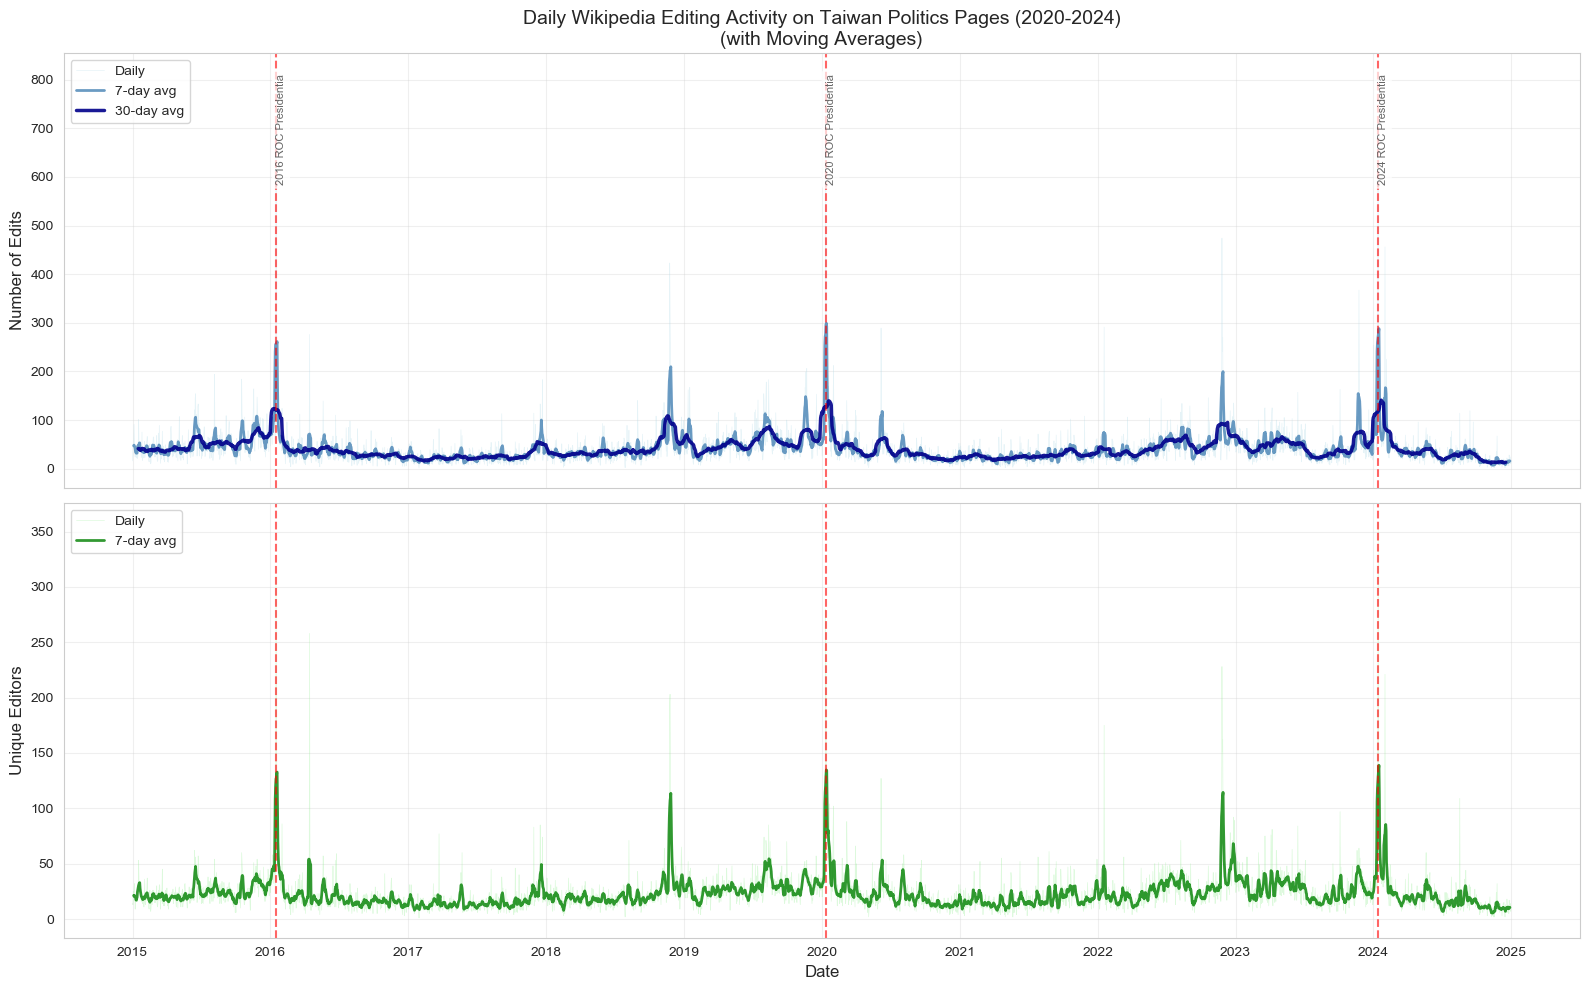


Peak editing day: 2020-01-11
Peak edits: 814 edits
Average daily edits: 41.1


In [14]:
# Aggregate daily activity across all pages
daily_aggregate = df_daily.groupby('date').agg({
    'num_edits': 'sum',
    'unique_editors': 'sum'
}).reset_index()

# Calculate moving averages (7-day and 30-day)
daily_aggregate['ma7_edits'] = daily_aggregate['num_edits'].rolling(window=7, center=True).mean()
daily_aggregate['ma30_edits'] = daily_aggregate['num_edits'].rolling(window=30, center=True).mean()
daily_aggregate['ma7_editors'] = daily_aggregate['unique_editors'].rolling(window=7, center=True).mean()

# Create time series plot with moving averages
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Plot 1: Edit volume
# Daily data (light, in background)
axes[0].plot(daily_aggregate['date'], daily_aggregate['num_edits'], 
            linewidth=0.5, alpha=0.3, color='lightblue', label='Daily')
# 7-day moving average (main line)
axes[0].plot(daily_aggregate['date'], daily_aggregate['ma7_edits'], 
            linewidth=2, alpha=0.8, color='steelblue', label='7-day avg')
# 30-day moving average (trend)
axes[0].plot(daily_aggregate['date'], daily_aggregate['ma30_edits'], 
            linewidth=2.5, alpha=0.9, color='darkblue', label='30-day avg')

axes[0].set_ylabel('Number of Edits', fontsize=12)
axes[0].set_title('Daily Wikipedia Editing Activity on Taiwan Politics Pages (2020-2024)\n(with Moving Averages)', 
                 fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper left', fontsize=10)

# Mark political events
for _, event in events.iterrows():
    axes[0].axvline(event['date'], color='red', linestyle='--', alpha=0.6, linewidth=1.5)
    # Add event labels (rotated)
    y_pos = axes[0].get_ylim()[1] * 0.95
    axes[0].text(event['date'], y_pos, 
                event['name'][:20], rotation=90, 
                verticalalignment='top', fontsize=8, alpha=0.7,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# Plot 2: Unique editors
axes[1].plot(daily_aggregate['date'], daily_aggregate['unique_editors'], 
            linewidth=0.5, alpha=0.3, color='lightgreen', label='Daily')
axes[1].plot(daily_aggregate['date'], daily_aggregate['ma7_editors'], 
            linewidth=2, alpha=0.8, color='green', label='7-day avg')
axes[1].set_ylabel('Unique Editors', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper left', fontsize=10)

# Mark political events
for _, event in events.iterrows():
    axes[1].axvline(event['date'], color='red', linestyle='--', alpha=0.6, linewidth=1.5)

plt.tight_layout()
plt.show()

print(f"\nPeak editing day: {daily_aggregate.loc[daily_aggregate['num_edits'].idxmax(), 'date'].date()}")
print(f"Peak edits: {daily_aggregate['num_edits'].max()} edits")
print(f"Average daily edits: {daily_aggregate['num_edits'].mean():.1f}")


### 2b. Interactive Time Series

Interactive version (requires plotly).


In [15]:
# Interactive plot with Plotly (install with: conda install plotly)
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    
    # Create figure with subplots
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        subplot_titles=('Edit Volume (with 7-day Moving Average)', 'Unique Editors (with 7-day Moving Average)'),
        vertical_spacing=0.1
    )
    
    # Add edit traces
    fig.add_trace(
        go.Scatter(x=daily_aggregate['date'], y=daily_aggregate['num_edits'],
                  mode='lines', name='Daily Edits', 
                  line=dict(color='lightblue', width=1), opacity=0.3),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=daily_aggregate['date'], y=daily_aggregate['ma7_edits'],
                  mode='lines', name='7-day Avg Edits',
                  line=dict(color='steelblue', width=2)),
        row=1, col=1
    )
    
    # Add editor traces
    fig.add_trace(
        go.Scatter(x=daily_aggregate['date'], y=daily_aggregate['unique_editors'],
                  mode='lines', name='Daily Editors',
                  line=dict(color='lightgreen', width=1), opacity=0.3),
        row=2, col=1
    )
    fig.add_trace(
        go.Scatter(x=daily_aggregate['date'], y=daily_aggregate['ma7_editors'],
                  mode='lines', name='7-day Avg Editors',
                  line=dict(color='green', width=2)),
        row=2, col=1
    )
    
    # Add event markers using scatter traces (most reliable method)
    for _, event in events.iterrows():
        # Get y-axis ranges
        max_edits = daily_aggregate['num_edits'].max()
        max_editors = daily_aggregate['unique_editors'].max()
        
        # Add vertical line as scatter trace for edits plot
        fig.add_trace(
            go.Scatter(
                x=[event['date'], event['date']],
                y=[0, max_edits],
                mode='lines',
                line=dict(color='red', width=1.5, dash='dash'),
                showlegend=False,
                hoverinfo='skip'
            ),
            row=1, col=1
        )
        
        # Add vertical line for editors plot
        fig.add_trace(
            go.Scatter(
                x=[event['date'], event['date']],
                y=[0, max_editors],
                mode='lines',
                line=dict(color='red', width=1.5, dash='dash'),
                showlegend=False,
                hoverinfo='skip'
            ),
            row=2, col=1
        )
    
    # Update layout
    fig.update_layout(
        height=800,
        title_text="Interactive: Wikipedia Editing Activity on Taiwan Politics Pages (2020-2024)<br><sub>Red dashed lines mark political events</sub>",
        hovermode='x unified',
        showlegend=True
    )
    
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_yaxes(title_text="Number of Edits", row=1, col=1)
    fig.update_yaxes(title_text="Unique Editors", row=2, col=1)
    
    # Show interactive plot
    fig.show()
    
    print("Note: Red dashed lines mark political events")
    
except ImportError:
    print("Plotly not installed. To use interactive plots, run: conda install plotly")
except Exception as e:
    print(f"Error creating interactive plot: {e}")


Note: Red dashed lines mark political events


## 3. Event Analysis: Pre vs Post Comparison


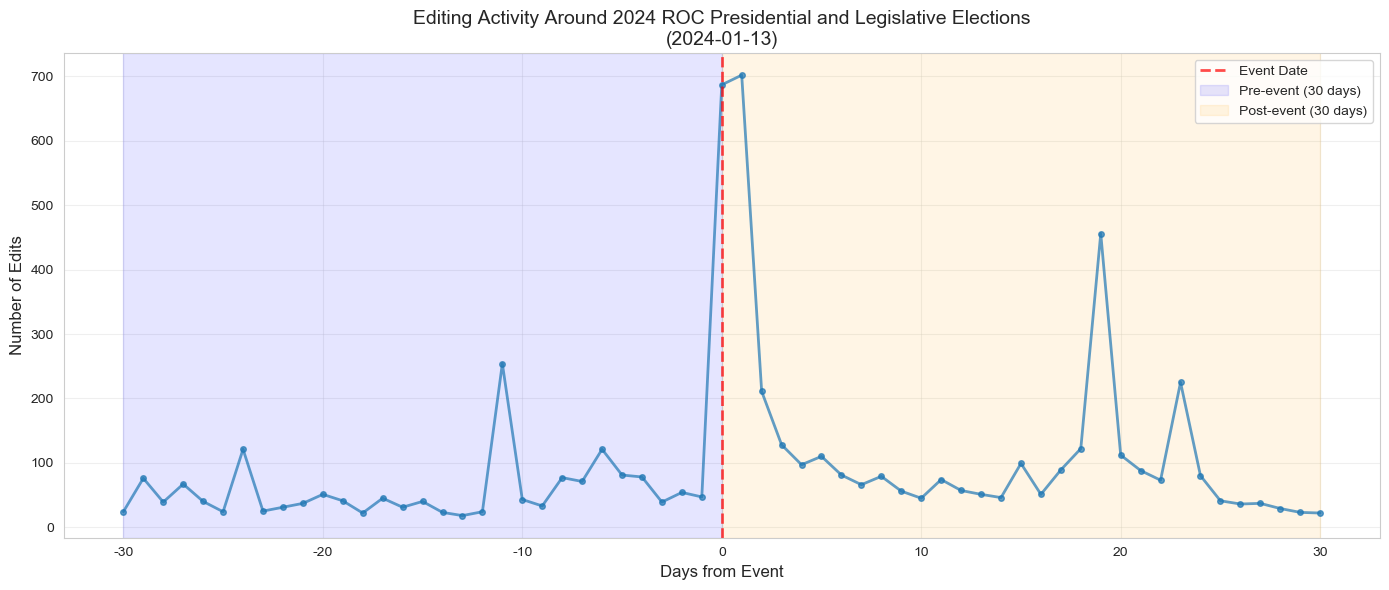


2024 ROC Presidential and Legislative Elections
Pre-event average (30 days): 55.9 edits/day
Post-event average (30 days): 112.9 edits/day
Change: +101.9%


In [16]:
# Analyze editing activity around political events
def analyze_event_impact(event_date, event_name, window_days=30):
    """Analyze editing activity before and after an event"""
    pre_start = event_date - timedelta(days=window_days)
    post_end = event_date + timedelta(days=window_days)
    
    # Filter data
    mask = (daily_aggregate['date'] >= pre_start) & (daily_aggregate['date'] <= post_end)
    event_data = daily_aggregate[mask].copy()
    
    # Label periods
    event_data['period'] = 'pre'
    event_data.loc[event_data['date'] > event_date, 'period'] = 'post'
    event_data.loc[event_data['date'] == event_date, 'period'] = 'event'
    event_data['days_from_event'] = (event_data['date'] - event_date).dt.days
    
    return event_data

# Analyze 2024 election
event_2024 = events[events['event_id'] == 'tw_election_2024'].iloc[0]
event_data_2024 = analyze_event_impact(event_2024['date'], event_2024['name'])

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

# Plot editing activity
ax.plot(event_data_2024['days_from_event'], event_data_2024['num_edits'], 
       marker='o', linewidth=2, markersize=4, alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Event Date', alpha=0.7)
ax.axvspan(-30, 0, alpha=0.1, color='blue', label='Pre-event (30 days)')
ax.axvspan(0, 30, alpha=0.1, color='orange', label='Post-event (30 days)')

ax.set_xlabel('Days from Event', fontsize=12)
ax.set_ylabel('Number of Edits', fontsize=12)
ax.set_title(f'Editing Activity Around {event_2024["name"]}\n({event_2024["date"].date()})', 
            fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate statistics
pre_avg = event_data_2024[event_data_2024['period'] == 'pre']['num_edits'].mean()
post_avg = event_data_2024[event_data_2024['period'] == 'post']['num_edits'].mean()
change_pct = ((post_avg - pre_avg) / pre_avg) * 100

print(f"\n{event_2024['name']}")
print("=" * 60)
print(f"Pre-event average (30 days): {pre_avg:.1f} edits/day")
print(f"Post-event average (30 days): {post_avg:.1f} edits/day")
print(f"Change: {change_pct:+.1f}%")


## 4. Page-Level Analysis


In [17]:
# Interactive Page-Level Analysis with Plotly
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    import numpy as np
    
    # Get top 20 pages
    top_20 = df_pages.nlargest(20, 'total_edits')
    
    # Create subplots
    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=(
            'Top 20 Most Edited Pages',
            'Distribution of Edit Volume',
            'Concentration of Editing Activity'
        ),
        column_widths=[0.35, 0.3, 0.35],
        horizontal_spacing=0.12
    )
    
    # 1. Top 20 pages (horizontal bar)
    fig.add_trace(
        go.Bar(
            y=top_20['page_title'][::-1],  # Reverse to show highest at top
            x=top_20['total_edits'][::-1],
            orientation='h',
            marker=dict(color='steelblue'),
            hovertemplate='<b>%{y}</b><br>Edits: %{x:,}<br>Editors: %{customdata:,}<extra></extra>',
            customdata=top_20['unique_editors'][::-1]
        ),
        row=1, col=1
    )
    
    # 2. Distribution histogram
    fig.add_trace(
        go.Histogram(
            x=df_pages['total_edits'],
            nbinsx=50,
            marker=dict(color='steelblue', line=dict(color='black', width=1)),
            hovertemplate='Edits: %{x}<br>Pages: %{y}<extra></extra>'
        ),
        row=1, col=2
    )
    
    # Add median line to histogram
    median_edits = df_pages['total_edits'].median()
    fig.add_vline(
        x=median_edits,
        line_dash="dash",
        line_color="red",
        annotation_text=f"Median: {median_edits:.0f}",
        annotation_position="top",
        row=1, col=2
    )
    
    # 3. Cumulative concentration curve (Lorenz-like)
    sorted_edits = df_pages.sort_values('total_edits', ascending=False)
    cumulative_pct = (sorted_edits['total_edits'].cumsum() / sorted_edits['total_edits'].sum() * 100)
    page_pct = np.arange(1, len(sorted_edits) + 1) / len(sorted_edits) * 100
    
    # Concentration curve
    fig.add_trace(
        go.Scatter(
            x=page_pct,
            y=cumulative_pct,
            mode='lines',
            line=dict(color='steelblue', width=2),
            name='Actual',
            hovertemplate='%{x:.1f}% of pages<br>%{y:.1f}% of edits<extra></extra>'
        ),
        row=1, col=3
    )
    
    # Perfect equality line
    fig.add_trace(
        go.Scatter(
            x=[0, 100],
            y=[0, 100],
            mode='lines',
            line=dict(color='red', width=2, dash='dash'),
            name='Perfect equality',
            hovertemplate='Perfect equality<extra></extra>'
        ),
        row=1, col=3
    )
    
    # Update layout
    fig.update_xaxes(title_text="Total Edits", row=1, col=1)
    fig.update_xaxes(title_text="Total Edits", row=1, col=2)
    fig.update_xaxes(title_text="Cumulative % of Pages", row=1, col=3)
    
    fig.update_yaxes(title_text="", row=1, col=1)
    fig.update_yaxes(title_text="Number of Pages", row=1, col=2)
    fig.update_yaxes(title_text="Cumulative % of Edits", row=1, col=3)
    
    fig.update_layout(
        height=600,
        showlegend=True,
        title_text="Page-Level Editing Activity Analysis (Interactive)",
        title_x=0.5,
        hovermode='closest'
    )
    
    fig.show()
    
    # Print concentration statistics
    print("\n" + "="*60)
    print("EDITING CONCENTRATION STATISTICS")
    print("="*60)
    
    total_edits = sorted_edits['total_edits'].sum()
    print(f"Total pages: {len(df_pages):,}")
    print(f"Total edits: {total_edits:,}")
    print(f"\nConcentration:")
    print(f"  Top 5 pages:  {(sorted_edits.head(5)['total_edits'].sum() / total_edits * 100):>6.1f}% of all edits")
    print(f"  Top 10 pages: {(sorted_edits.head(10)['total_edits'].sum() / total_edits * 100):>6.1f}% of all edits")
    print(f"  Top 20 pages: {(sorted_edits.head(20)['total_edits'].sum() / total_edits * 100):>6.1f}% of all edits")
    print(f"  Top 50 pages: {(sorted_edits.head(50)['total_edits'].sum() / total_edits * 100):>6.1f}% of all edits")
    
    print(f"\nDistribution:")
    print(f"  Median edits per page: {df_pages['total_edits'].median():,.0f}")
    print(f"  Mean edits per page:   {df_pages['total_edits'].mean():,.0f}")
    print(f"  Std deviation:         {df_pages['total_edits'].std():,.0f}")
    
    print(f"\nTop 5 Most Edited Pages:")
    for i, row in sorted_edits.head(5).iterrows():
        print(f"  {row['page_title'][:50]:50s} {row['total_edits']:>6,} edits ({row['unique_editors']:>4,} editors)")
    
except ImportError:
    print("Plotly not installed. Install with: conda install plotly")
    
    # Fallback: Static matplotlib version (Top 20 only)
    top_20 = df_pages.nlargest(20, 'total_edits')
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(range(len(top_20)), top_20['total_edits'][::-1])
    ax.set_yticks(range(len(top_20)))
    ax.set_yticklabels(top_20['page_title'][::-1], fontsize=10)
    ax.set_xlabel('Total Edits', fontsize=11)
    ax.set_title('Top 20 Most Edited Pages', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()



EDITING CONCENTRATION STATISTICS
Total pages: 775
Total edits: 150,146

Concentration:
  Top 5 pages:    14.1% of all edits
  Top 10 pages:   25.5% of all edits
  Top 20 pages:   40.1% of all edits
  Top 50 pages:   61.2% of all edits

Distribution:
  Median edits per page: 46
  Mean edits per page:   194
  Std deviation:         531

Top 5 Most Edited Pages:
  中國國民黨                                               4,708 edits (1,615 editors)
  2018年中華民國直轄市長及縣市長選舉                                 4,416 edits ( 933 editors)
  2022年中華民國直轄市長及縣市長選舉                                 4,231 edits ( 691 editors)
  2020年中華民國立法委員選舉                                     3,885 edits ( 747 editors)
  蔡英文                                                 3,858 edits (1,003 editors)


## 5. Weekly patterns, Monthly trends


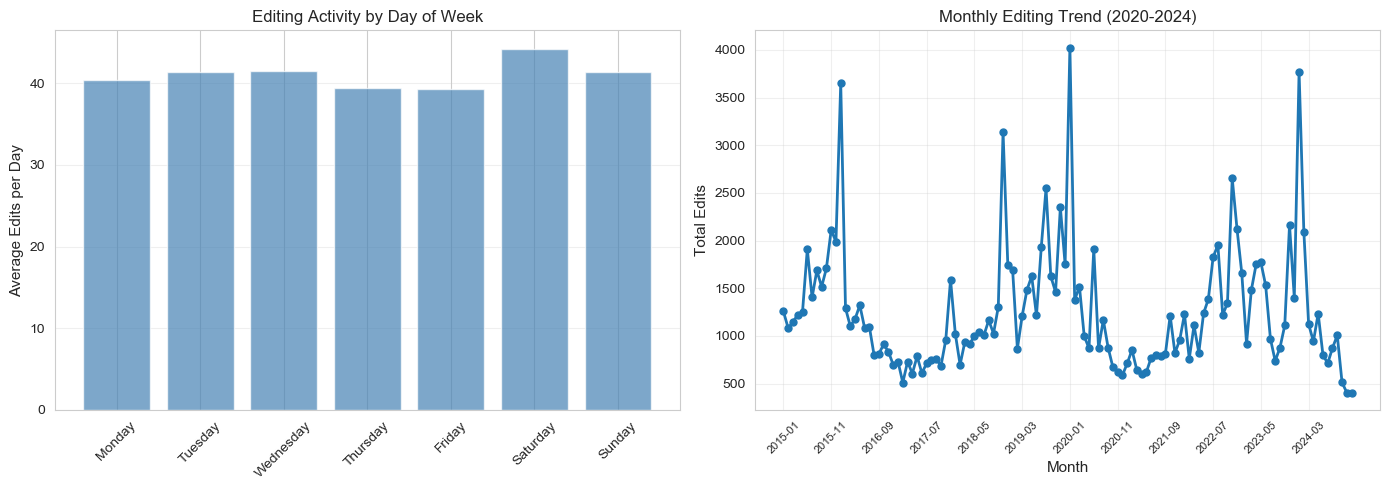

In [18]:
# Day of week patterns
daily_aggregate['dayofweek'] = daily_aggregate['date'].dt.dayofweek
daily_aggregate['month'] = daily_aggregate['date'].dt.to_period('M')

# Aggregate by day of week
dow_stats = daily_aggregate.groupby('dayofweek').agg({
    'num_edits': 'mean',
    'unique_editors': 'mean'
}).reset_index()

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day of week pattern
axes[0].bar(dow_stats['dayofweek'], dow_stats['num_edits'], color='steelblue', alpha=0.7)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_names, rotation=45)
axes[0].set_ylabel('Average Edits per Day', fontsize=11)
axes[0].set_title('Editing Activity by Day of Week', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Monthly trend
monthly_stats = daily_aggregate.groupby('month').agg({
    'num_edits': 'sum'
}).reset_index()
monthly_stats['month_str'] = monthly_stats['month'].astype(str)

axes[1].plot(range(len(monthly_stats)), monthly_stats['num_edits'], marker='o', linewidth=2, markersize=5)
axes[1].set_xlabel('Month', fontsize=11)
axes[1].set_ylabel('Total Edits', fontsize=11)
axes[1].set_title('Monthly Editing Trend (2020-2024)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
# Show every 6th month label
step = max(1, len(monthly_stats) // 12)
axes[1].set_xticks(range(0, len(monthly_stats), step))
axes[1].set_xticklabels(monthly_stats['month_str'].iloc[::step], rotation=45, fontsize=8)

plt.tight_layout()
plt.show()


## 7. Next steps

1. Implement the design outlined in the prospectus (3 hypotheses)